# Brownian Motion in Cells (BMC) Simulation Exercise

This exercise shows how to simulate the motion of single and multiple particles in one and two dimensions using Matlab. You will discover some useful ways to visualize and analyze particle motion data, as well as learn the Matlab code to accomplish these tasks. Once you understand the simulations, you can tweak the code to simulate the actual experimental conditions you choose for your study of Brownian motion of synthetic beads. These simulations will generate the predictions you can test in your experiment.

**You should be following along in your own notebook as you read through this one - do not modify this one!** Create your own Jupyter notebook, then rewrite the cells (making your own modifications as necessary) and adjust the simulation parameters. Be prepared to explain the contents of your code and the plots that result!

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Simulating Single Particle Trajectories

This exercise shows how to simulate the motion of a single particle in one and two dimensions.

### One Dimensional Brownian Motion

Brownian motion in one dimension is composed of a sequence of normally distributed random displacements. The randn function returns a matrix of a normally distributed random numbers with standard deviation 1. The two arguments specify the size of the matrix, which will be 1xN in the example below.

The first step in simulating this process is to generate a vector of random displacements. The commands to do this are shown below. N is the number of samples to generate.

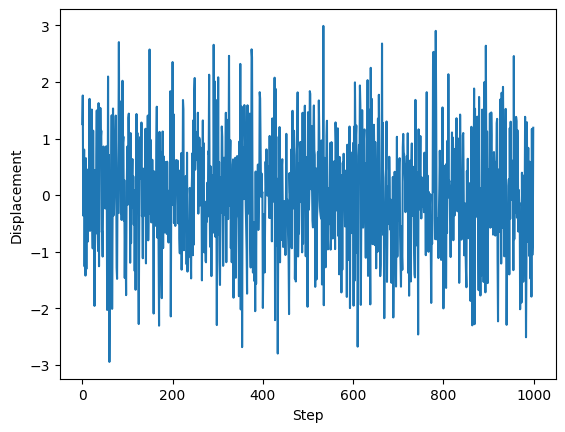

In [2]:
N = 1000
displacements = np.random.randn(N)
plt.plot(displacements)
plt.ylabel('Displacement')
plt.xlabel('Step')
plt.show()

### Distribution of Displacements

Have a look at the distribution of the randomly generated displacements. The hist command plots a histogram of the values. The second argument - 25 - specifies that Python should divide the values into 25 bins.

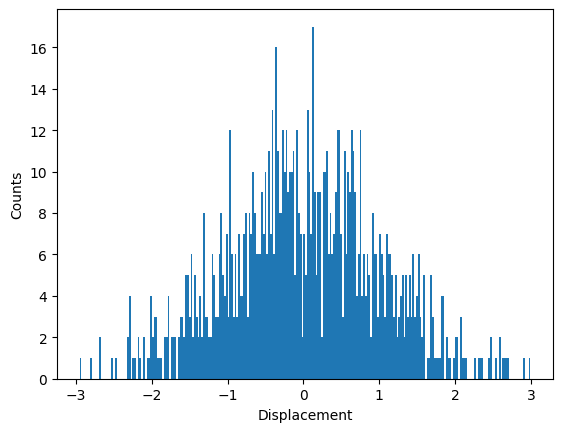

In [3]:
plt.hist(displacements, bins=256)
plt.ylabel('Counts')
plt.xlabel('Displacement')
plt.show()

### Convert displacements to position

Now we have some appropriate random displacements. Their sum represents a particle trajectory in 1 dimension. The NumPy function cumsum returns the cumulative sum of a vector. The following commands take the cumulative sum of displacement and save the result in a vector called x.

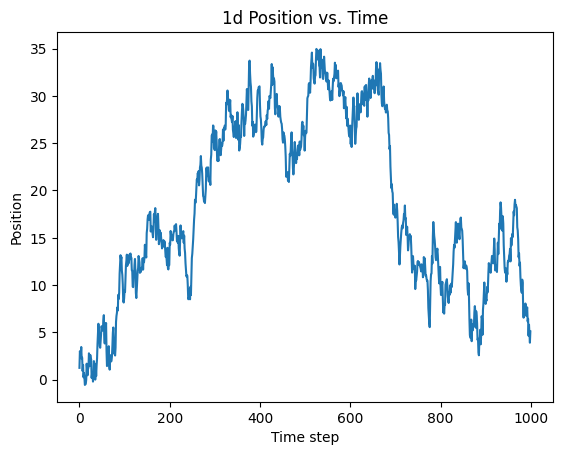

In [4]:
x = np.cumsum(displacements)
plt.plot(x)
plt.xlabel('Time step')
plt.ylabel('Position')
plt.title('1d Position vs. Time')
plt.show()

# Two dimensional particle simulation

Extending this to two dimensions is simple. Since all directions are (assumed to be) equivalent, all we need to do is generate two vectors of random displacements. The vector of displacements saved in an object which is an instance of a Python class called `Particle`. The x and y position vectors are stored in members of the structure. This data could also have been saved as a 2xN matrix. Using a structure has the important advantage that a meaningful name can be assigned to each member. This good practice makes your code much more readable.

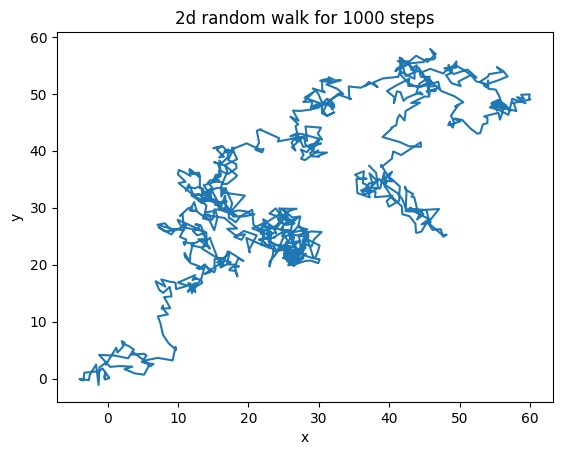

In [5]:
class Particle():
    def __init__(self, N, k=1, xoff=0, yoff=0):
        self.N = N
        self.dx = k*np.random.randn(N) + k*xoff
        self.dy = k*np.random.randn(N) + k*yoff
        self.x = np.cumsum(self.dx)
        self.y = np.cumsum(self.dy)
        self.dr_squared = self.dx**2 + self.dy**2
        self.displacement_squared = self.x **2 + self.y **2
    
    def D_calc(self, dimensions, tau):
        self.D = np.mean(self.dr_squared) / ( 2 * dimensions * tau )
        self.standard_error = np.std(self.dr_squared) / ( 2 * dimensions * tau * np.sqrt(self.N) )

N = 1000
particle = Particle(N)
plt.plot(particle.x, particle.y)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'2d random walk for {N} steps')
plt.show()

### Compute the Displacement Squared

The displacement squared is equal to the x coordinate squared plus the y coordinate squared. Since the simulated particle always start at (0,0), it is unnecessary to subtract off the initial position (as will be necessary with the data you gather in the lab).

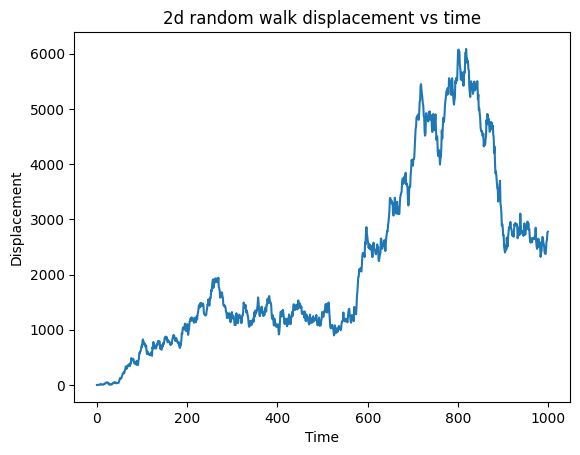

In [6]:
plt.plot(particle.displacement_squared)
plt.xlabel('Time')
plt.ylabel('Displacement')
plt.title('2d random walk displacement vs time')
plt.show()

### Theoretical Value of D

The theoretical value of the diffusion coefficient, D, is given by $$D=\frac{k_BT}{3\pi\eta d}$$ where T = temperature (Kelvin), $k_B$ = Boltzmann's constant, $\eta$ = viscosity, and d = diameter.

Note that the units of D are length squared divided by time. See the lab writeup for more information. Let's compute D for a 1 micron particle in water at 293 degrees Kelvin.

In [7]:
#D for a 1 micron particle in water at 293 degrees Kelvin.
d    = 1.0e-6;              # diameter in meters
eta  = 1.0e-3;              # viscosity of water in SI units (Pascal-seconds) at 293 K
kB   = 1.38e-23;            # Boltzmann constant
T    = 293;                 # Temperature in degrees Kelvin

D    = kB * T / (3 * np.pi * eta * d)
print(D)

4.2901806459851315e-13


### A more realistic particle -- Getting the Units Right

So far, we have been looking at simulated particles with a mean squared displacement of 1 unit per time interval. To accurately model a real particle, it is necessary to adjust the distribution of random displacements to match the experimental conditions.

According to theory, the mean squared displacement of the particle is proportional to the time interval, $$\langle\mid \vec{r}(t+\tau) - \vec{r}(t)\mid^2\rangle = 2dD\pi \tau,$$ where $\vec{r}(t)$ = position, d = number of dimensions, D = diffusion coefficient, and $\tau$ = time interval.

To generate the correct distribution, the output from randn (which has a standard normal distribution) must be scaled by the factor k.

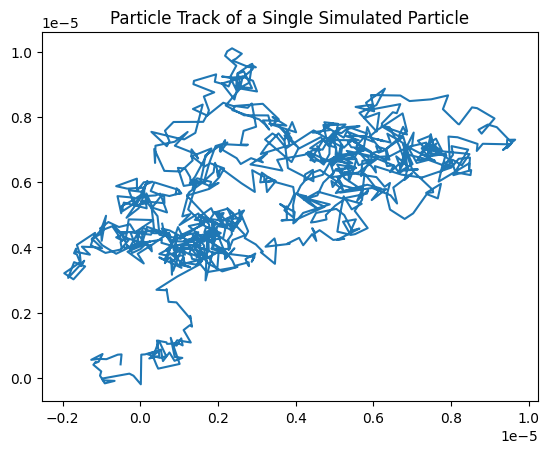

In [8]:
dimensions = 2 # two dimensional simulation
tau = 0.1 # time interval in seconds
time = tau * np.array(range(N)) # create a time vector for plotting

k = np.sqrt(D * dimensions * tau)
dx = k * np.random.randn(N)
dy = k * np.random.randn(N)

x = np.cumsum(dx)
y = np.cumsum(dy)

dSquaredDisplacement = (dx ** 2) + (dy ** 2)
squaredDisplacement = ( x ** 2) + ( y ** 2)

plt.plot(x,y)
plt.title('Particle Track of a Single Simulated Particle')
plt.show()

### Displacement Squared Plot

Theory predicts that the displacement should increase in proportion to the square root of time. The theoretical value of displacement squared is plotted with a thick black line. Since displacement is expected to increase with the square root of time, displacement squared is a straight line in the plot. With only a single particle and a small number of samples, deviation from the line can be quite large.

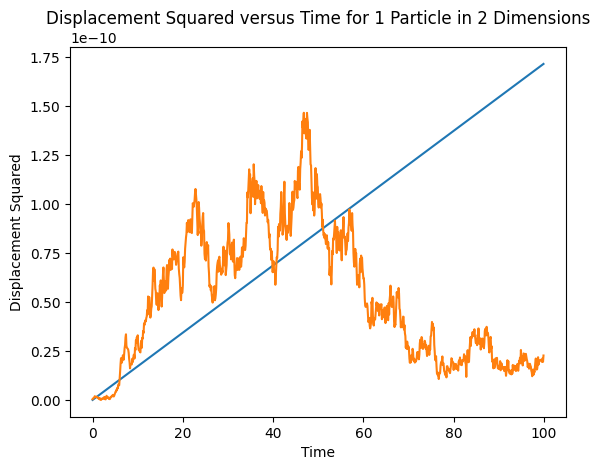

In [9]:
plt.plot(time, np.array(range(N)) * 2*k**2) # plot theoretical line
plt.plot(time, squaredDisplacement)
plt.xlabel('Time')
plt.ylabel('Displacement Squared')
plt.title('Displacement Squared versus Time for 1 Particle in 2 Dimensions')
plt.show()

### Estimating D from the Simulated Data

Solving for D gives $$D = \sqrt{\langle\mid \vec{r}(t+\tau) - \vec{r}(t)\mid^2\rangle/2d\tau}$$ The best estimate of the value of D from the simulated data is:

In [10]:
simulatedD = np.mean( dSquaredDisplacement ) / ( 2 * dimensions * tau )
print(simulatedD)

4.273009817650477e-13


### Uncertainty in the Estimate

The likely error of this measurement decreases as the square root of the number of samples. This will be discussed in more detail later.

In [11]:
standardError = np.std( dSquaredDisplacement ) / ( 2 * dimensions * tau * np.sqrt(N) )
actualError = D - simulatedD
print(standardError)
print(actualError)

1.35618244504736e-14
1.7170828334654732e-15


### Systematic Error -- Bulk Flow in the Solvent

Sometimes, evaporation or uneven heating of the solvent will cause a flow to occur on the slide you are observing. We can model this easily. The following code models a flow with a magnitude 0.5 k in the x direction and 0.1 k in the y direction.

4.369287425970445e-13
1.3831789900522944e-14
-7.910677998531336e-15


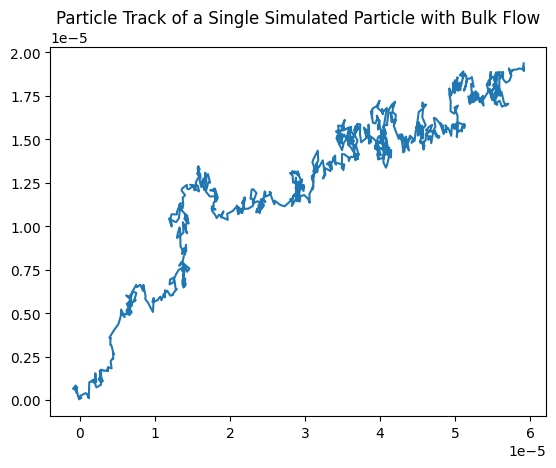

In [12]:
dx = dx + 0.2 * k
dy = dy + 0.05 * k

x = np.cumsum(dx)
y = np.cumsum(dy)

dSquaredDisplacement = (dx ** 2) + (dy ** 2)
squaredDisplacement = ( x ** 2) + ( y ** 2)

simulatedD    = np.mean( dSquaredDisplacement ) / ( 2 * dimensions * tau )
standardError = np.std(  dSquaredDisplacement ) / ( 2 * dimensions * tau * np.sqrt(N) )
actualError = D - simulatedD
print(simulatedD)
print(standardError)
print(actualError)

plt.plot(x,y)
plt.title('Particle Track of a Single Simulated Particle with Bulk Flow')
plt.show()

### Displacement Squared in the Presence of Bulk Flow

Notice how the plot of displacement squared diverges from the theoretical value. It has a distinct quadratic component. The magnitude of this error increases dramatically with time. This suggests that the error caused by bulk flow can be minimized by using the shortest possible sampling period. But there's a catch. As you increase the sampling rate, the amount of noise from the motion tracking algorithm goes up. A tenth of a second works pretty well for the particles you will observe in the lab. If you have time, take a few movies at a different rates to see the effect.

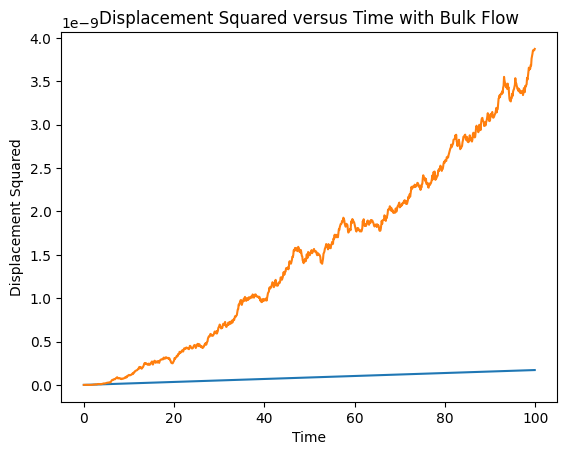

In [13]:
plt.plot(time, np.array(range(N)) * 2*k**2 ) # plot theoretical line
plt.plot(time, squaredDisplacement)
plt.xlabel('Time')
plt.ylabel('Displacement Squared')
plt.title('Displacement Squared versus Time with Bulk Flow')
plt.show()

# Simulating Multiple Particles

When you take your data in the lab, you will make movies of many particles. You will use a Python program to extract particle tracks from these movies. Because particles drift out of view and go in and out of focus, most movies will be about 5 seconds long at a sample rate of 10 Hz or so. Let's simulate this. 

### Using a For Loop to Generate Multiple Data Sets

A for loop is the key to generating multiple particle simulations. The results of the simulations are stored in an array of `Particle` objects. For example, `particle[3]` refers to a `Particle` object containing the results of simulation number 3. The expression `particle[3].D` is the estimated value of D for simulation number 3.

### `simulate_particles` Function

Typing all of this out every time we wanted to simulate multiple particles would be quite annoying. Fortunately, all of the commands to generate multiple particle tracks can be combined into in a single function called `simulate_particles`.

In [14]:
particleCount = 10
N = 50
tau = .1

def simulate_particles(particleCount, N, tau):
    time = tau*np.arange(N)
    particle = [0 for i in range(particleCount)] # create an empty cell array to hold the results
    for i in range(particleCount):
        particle[i] = Particle(N, k)
        particle[i].D_calc(dimensions=2, tau=tau)
    for i in particle:
        plt.plot(i.x, i.y)
    plt.xlabel('X position (m)')
    plt.ylabel('Y position (m)')
    plt.title('Combined particle tracks')
    return time, particle

### Look at the Results

The following code plots all of the generated particle tracks on a single set of axes, each in a random color.

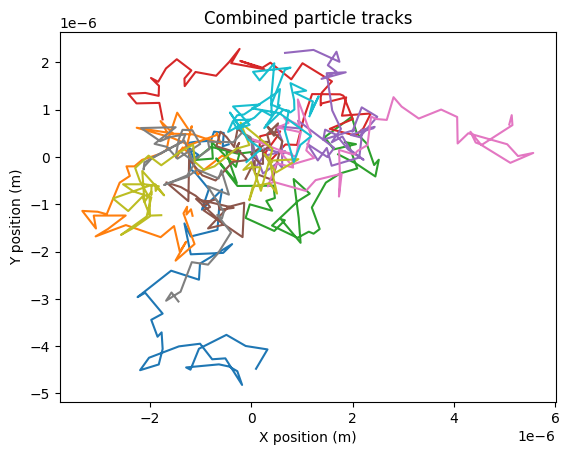

In [15]:
time, particles = simulate_particles(particleCount, N, tau)
plt.show()

### Displacement Squared

The following plot shows displacement squared versus time for all of the particles. The ensemble average of all the displacements is shown with a thick black line. The theoretical value of displacement squared is plotted with a thick blue line. Since displacement is expected to increase with the square root of time, displacement squared is a straight line in the plot.

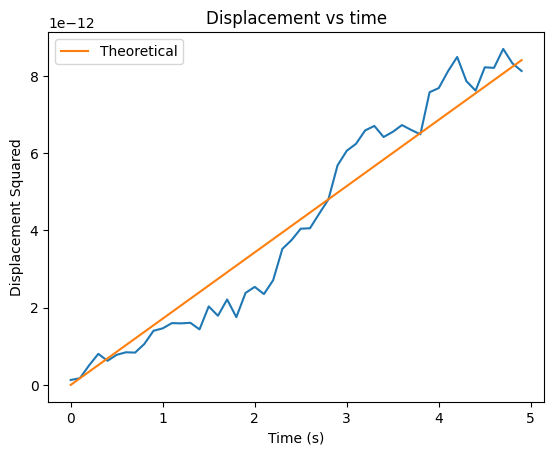

In [16]:
def displacement_plot(particles, time):
    avg_displacement = np.zeros(N)
    for i in particles:
        avg_displacement += i.displacement_squared
        #plt.plot(time, i.displacement_squared)
    avg_displacement /= len(particles)
    plt.plot(time, avg_displacement)
    plt.plot(time, np.arange(N) * 2*k**2, label='Theoretical')
    plt.xlabel('Time (s)')
    plt.ylabel('Displacement Squared')
    plt.title('Displacement vs time')
    plt.legend()

displacement_plot(particles, time)
plt.show()

### Estimated Value of D

This plot shows the computed value of D for each simulation with error bars. A thick blue line indicates the best overall estimate of D (the average of the D value from each simulation) along with error bars in green.

Average D estimate: 4.3946e-13
Uncertainty:        1.2907e-14


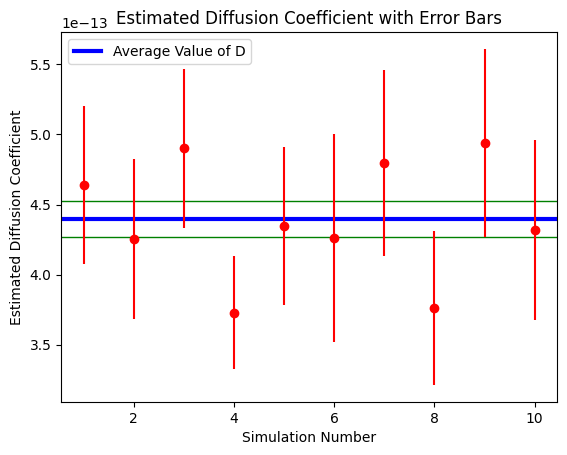

In [17]:
D_values = np.array([p.D for p in particles])
errors = np.array([p.standard_error for p in particles])

average_D = np.mean(D_values)
uncertainty = np.std(D_values) / np.sqrt(particleCount)

print(f"Average D estimate: {average_D:.4e}")
print(f"Uncertainty:        {uncertainty:.4e}")

sim_numbers = np.arange(1, particleCount + 1)

plt.figure()
plt.axhline(average_D, color='b', linewidth=3, label='Average Value of D')
plt.axhline(average_D + uncertainty, color='g', linewidth=1)
plt.axhline(average_D - uncertainty, color='g', linewidth=1)
plt.errorbar(sim_numbers, D_values, yerr=errors, fmt='ro')
plt.xlabel('Simulation Number')
plt.ylabel('Estimated Diffusion Coefficient')
plt.title('Estimated Diffusion Coefficient with Error Bars')
plt.legend(loc='upper left')
plt.show()

# Fancy Statistics and Plots

This section looks at the statistical properties of the simulated data in more detail. In particular, it discusses:

- Uncertainty in the estimate of the mean value of a random variable from a population of samples
- The effect of squaring a normally distributed random variable
- The assumption of statistical independence of samples

### A More Perfect Distribution

Did you notice that the distribution of random displacement values in the second section looked a little lopsided? Even with 1000 samples, there can be some noticeable deviations from the ideal distribution. A million samples looks quite a bit closer to the ideal.

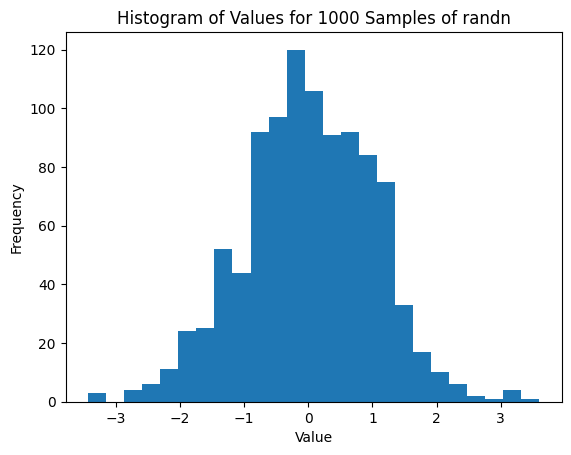

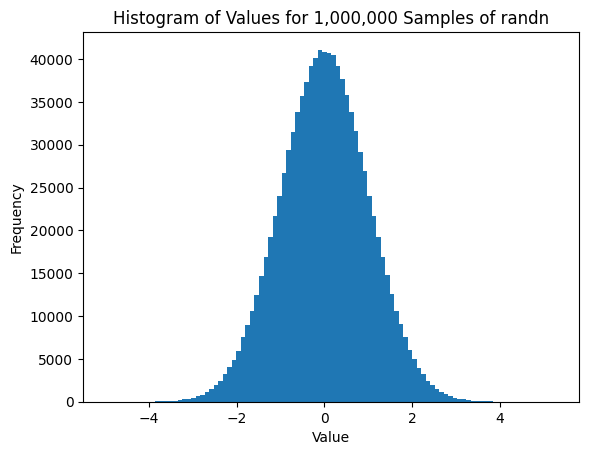

In [18]:
plt.figure()
plt.hist(np.random.randn(int(1e3)), bins=25)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Values for 1000 Samples of randn')
plt.show()

plt.figure()
plt.hist(np.random.randn(int(1e6)), bins=100)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Values for 1,000,000 Samples of randn')
plt.show()

### Sampling Uncertainty

This lab requires you to make an estimate of the average value of a random variable (actually, the square of a random variable) from a population of samples of that variable. The uncertainty in your estimate decreases with the square root of the number of samples, N. (That is, the standard error = 1/sqrt(N).)

This concept is illustrated in the following plot. To create the plot, fifty populations of N random samples are created for each value of N from 1 to 100. The mean value of each sample population is plotted with an 'x' versus N. The uncertainty appears to decrease as 1/sqrt(N) as expected. About two thirds of the values fall between the error bars (plotted in dark black).

Python note: check out the nested for loops used to create the plot.

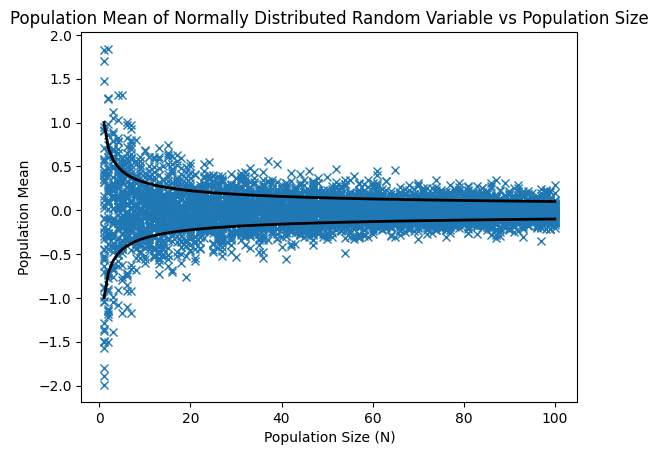

In [19]:
plt.figure()
for i in range(1, 101):
    for j in range(50):
        y = np.random.randn(i)
        m = np.mean(y)
        plt.plot(i, m, 'x', color='C0')

ns = np.arange(1, 101)
plt.plot(ns, 1 / np.sqrt(ns), 'k', linewidth=2)
plt.plot(ns, -1 / np.sqrt(ns), 'k', linewidth=2)
plt.xlabel('Population Size (N)')
plt.ylabel('Population Mean')
plt.title('Population Mean of Normally Distributed Random Variable vs Population Size')
plt.show()

### What Happens when you Square a Random Variable?

We did not estimate D in the simulations from the x and y displacements directly. Instead, we computed the mean squared value of dx and dy. What is the distribution of the resulting value? Adding the squares of two normally distributed random variables results in a chi-squared distribution (with two degrees of freedom) whose mean value equal to the sum of the variances of each variable. Here is what the chi-squared distribution looks like:

2.001108076731182
2.0011075543098023


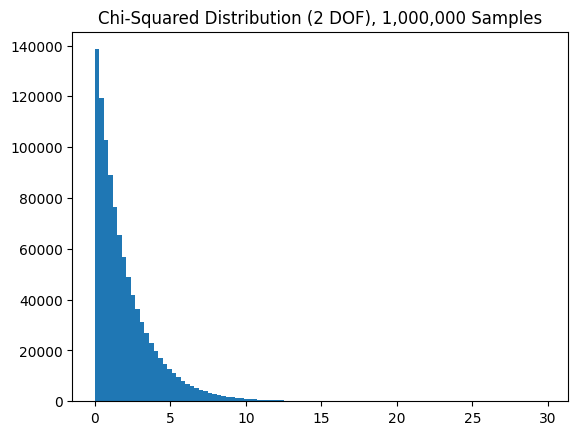

In [20]:
dx_big = np.random.randn(int(1e6))
dy_big = np.random.randn(int(1e6))
dr_squared_big = dx_big**2 + dy_big**2

print(np.mean(dr_squared_big))
print(np.var(dx_big) + np.var(dy_big))

plt.figure()
plt.hist(dr_squared_big, bins=100)
plt.title('Chi-Squared Distribution (2 DOF), 1,000,000 Samples')
plt.show()

### 100 Years of BMC Lab Data in 1 Second

So does the uncertainty of the squared and summed behave as expected? The following plot is a simulation of 5000 data sets - 50 at each value of N just as above. (This is what a plot of all the data from students doing the BMC lab for the next hundred years might look like. Some lazy groups decided to use very low values of N.)

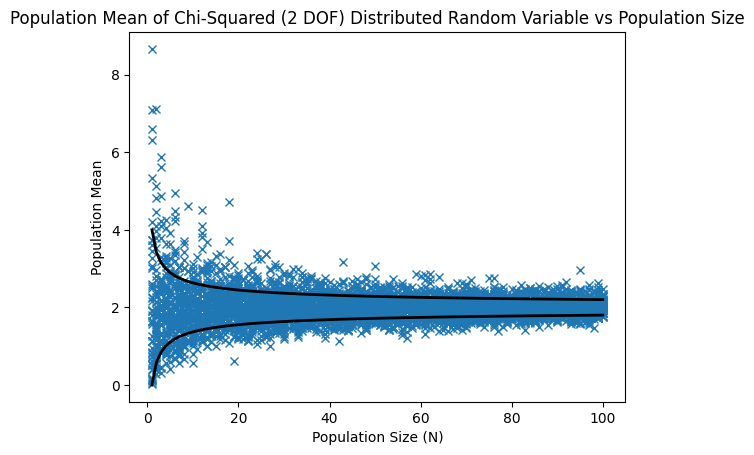

In [21]:
plt.figure()
for i in range(1, 101):
    for j in range(50):
        dx_s = np.random.randn(i)
        dy_s = np.random.randn(i)
        m = np.mean(dx_s**2 + dy_s**2)
        plt.plot(i, m, 'x', color='C0')

ns = np.arange(1, 101)
plt.plot(ns, 2 + 2 / np.sqrt(ns), 'k', linewidth=2)
plt.plot(ns, 2 - 2 / np.sqrt(ns), 'k', linewidth=2)
plt.xlabel('Population Size (N)')
plt.ylabel('Population Mean')
plt.title('Population Mean of Chi-Squared (2 DOF) Distributed Random Variable vs Population Size')
plt.show()

### Planning Your Time in the Lab

Sampling error sets a lower bound on the uncertainty in your estimate of the diffusion coefficient from experimental data. To plan your time in the lab, it will be important to understand how much data you should take for each experimental condition. Because the particles go out of focus and drift away from of the observation area, it can be difficult to make movies longer than about 5 seconds. At a frame rate of 10 frames per second, how many movies would you have to make to achieve a final uncertainty of 10%? 1%? .1%? What level of uncertainty will you try for in the lab?

### Auto Correlation - A Closer Look at the Data

The simulations so far have assumed that we are in the overdamped limit, or the inertia-less regime. This assumption makes generating simulated trajectories very easy - all you have to do is add up a bunch of properly distributed random numbers. Of course, just because something is convenient doesn't mean it's true.

There are many statistical tests for independence and normality. (My personal favorite is the Kolmogorov-Smirnov test – but never before 5:00 PM.) Auto and cross correlation are a good place to start testing for independence. Autocorrelation looks for a relationship between a variable and its past or future values. Cross correlation looks for a relationship between two variables. Matlab has a built in function to compute auto and cross correlations called xcorr.

By construction, the simulated displacements are independent. The change in position at one time should exhibit no relationship at all to the change at any other time. This can be verified with `np.correlate`, used in the `xcorr_coeff` function. If x is a vector, `xcorr_coeff(x)` returns the correlation of x with itself for all possible offsets. The length of the resulting autocorrelation sequence is 2N+1. The middle value always stands out because x correlates perfectly with itself when there is no offset. Specifying the mode `'full'` causes the `np.correlate` function to normalize this value to exactly 1 --perfect correlation.

Also notice that the autocorrelation sequence is symmetric about the origin.

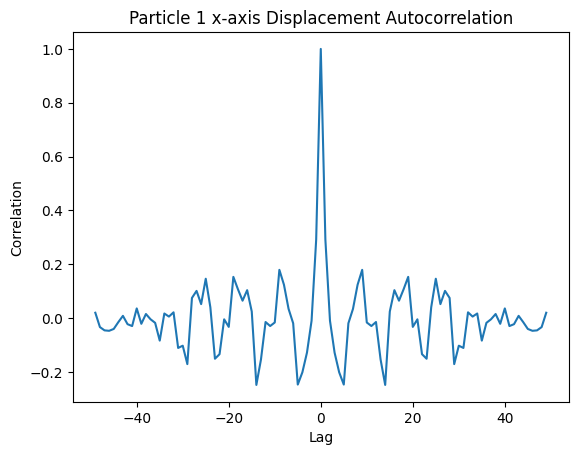

In [22]:
def xcorr_coeff(x, y=None):
    """Normalized cross-correlation, analogous to Matlab's xcorr(x, 'coeff')."""
    if y is None:
        y = x
    n = len(x)
    c = np.correlate(x, y, mode='full')
    c = c / (np.std(x) * np.std(y) * n)
    lags = np.arange(-(n - 1), n)
    return lags, c

lags, c = xcorr_coeff(particles[0].dx)

plt.figure()
plt.plot(lags, c)
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.title('Particle 1 x-axis Displacement Autocorrelation')
plt.show()

### Cross Correlation

With two vector arguments, `xcorr_coeff(x,y)` returns a cross correlation matrix. The cross correlation can be used to test the relationship (or lack thereof) between one particle's trajectory and another's. If two particles move independently, the cross correlations should be very small. The code below computes the cross correlation between the x displacements of particle simulations number 1 and 2.

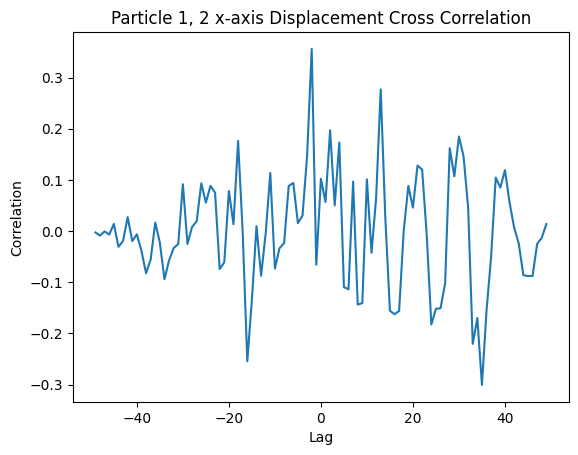

In [23]:
lags, c = xcorr_coeff(particles[0].dx, particles[1].dx)

plt.figure()
plt.plot(lags, c)
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.title('Particle 1, 2 x-axis Displacement Cross Correlation')
plt.show()

### Python Tricks

Python can generate (and plot) an amazing amount of data. For example, the `xcorr_coeff` function can compute the auto and cross correlations of a large set of data values. If A is an MxN matrix, using for loops with `xcorr_coeff` produces a size 2*M-1 x N^2 matrix whose columns contain the cross-correlation sequences for all combinations of the columns of A. The football shape of the data is a result of the way that the data is windowed when computing the correlation.

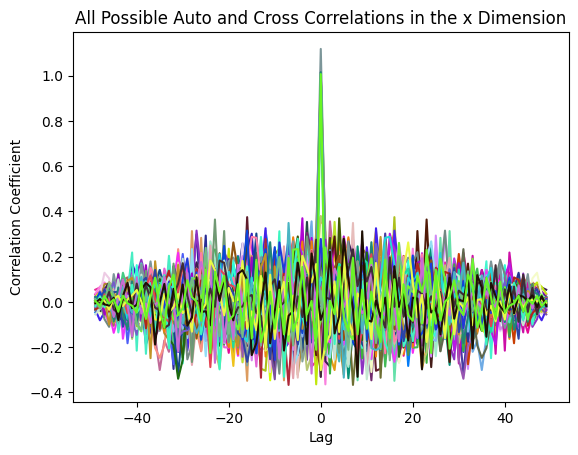

In [25]:
all_dx = np.array([p.dx for p in particles])   # shape (particleCount, N)

plt.figure()
for i in range(particleCount):
    for j in range(particleCount):
        lags, c = xcorr_coeff(all_dx[i], all_dx[j])
        plt.plot(lags, c, color=np.random.rand(3))

plt.xlabel('Lag')
plt.ylabel('Correlation Coefficient')
plt.title('All Possible Auto and Cross Correlations in the x Dimension')
plt.show()

### A Correlated Trajectory

So what does the autocorrelation sequence look like for a trajectory that is not generated from independent samples? In the following example, the displacement at each time interval depends in part on the displacement in the last interval plus a random number. The autocorrelation is not nearly as sharp as the one generated by independent random samples.

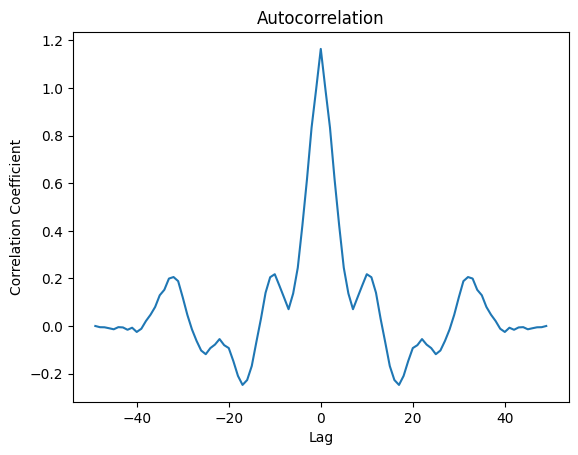

In [26]:
c_corr = 0.80   # degree of correlation; 0 to 1
step = np.random.randn(N)
x_corr = np.zeros(N)
x_corr[1] = np.random.randn()

for t in range(2, N):
    x_corr[t] = (c_corr * x_corr[t - 1]) + ((1 - c_corr) * step[t])

lags, c = xcorr_coeff(x_corr)

plt.figure()
plt.plot(lags, c)
plt.xlabel('Lag')
plt.ylabel('Correlation Coefficient')
plt.title('Autocorrelation')
plt.show()

# Conclusion

Remember, you should play with these simulations in a notebook of your own and be prepared to explain them to staff! These are crucial for understanding and analyzing the real data you will see in the BMC lab, as well as for forming your own ideas for investigations.